# Fit data

In [7]:
import numpy as np
def fit_model(x, y, degree=1):
    """
    Fit a polynomial

    Parameters
    x : array-like
        Input data
    y : array-like
        Output data
    degree : int
        Degree of polynomial (1, 2, or 3)

    Returns
    poly : numpy.poly1d
        Polynomial function
    """

    coeffs = np.polyfit(x, y, degree)
    poly = np.poly1d(coeffs)
    return poly


In [8]:
def volt_to_inch(v, model):
    """
    Convert voltage to predicted inches using chosen model.

    Parameters
    v : float or array-like
        Voltage value(s)
    model: numpy.poly1d
        Polynomial function

    Returns
    float or array
        Predicted inches
    """
    return model(v)


# print("Linear fit:")
# print(linear_model)

# print("2nd degree fit:")
# print(quad_model)

# print("3rd degree fit:")
# print(cubic_model)

In [9]:
# Example usage
import pandas as pd
# load from csv or enter data manually
#loading from csv
df = pd.read_csv('example_volt.csv')
inches = df["inch"]
volts = df["volt"]

#entering manually
# inches = [1,2,3,4,5,6,7,8,9,10]
# volts = [0.1 ,0.23,0.45 ,0.67 ,1.0 ,1.2 ,1.4 ,1.7 ,1.9, 2.15]

linear_model = fit_model(volts, inches, degree=1)
quad_model = fit_model(volts, inches, degree=2)
cubic_model = fit_model(volts, inches, degree=3)

x = 2  # voltage value
print(f"For voltage = {x}:")
print("Linear result:", volt_to_inch(x, linear_model))
print("2nd degree result:", volt_to_inch(x, quad_model))
print("3rd degree result:", volt_to_inch(x, cubic_model))

For voltage = 2:
Linear result: 9.401067179846045
2nd degree result: 9.34979292561884
3rd degree result: 9.3495084780733


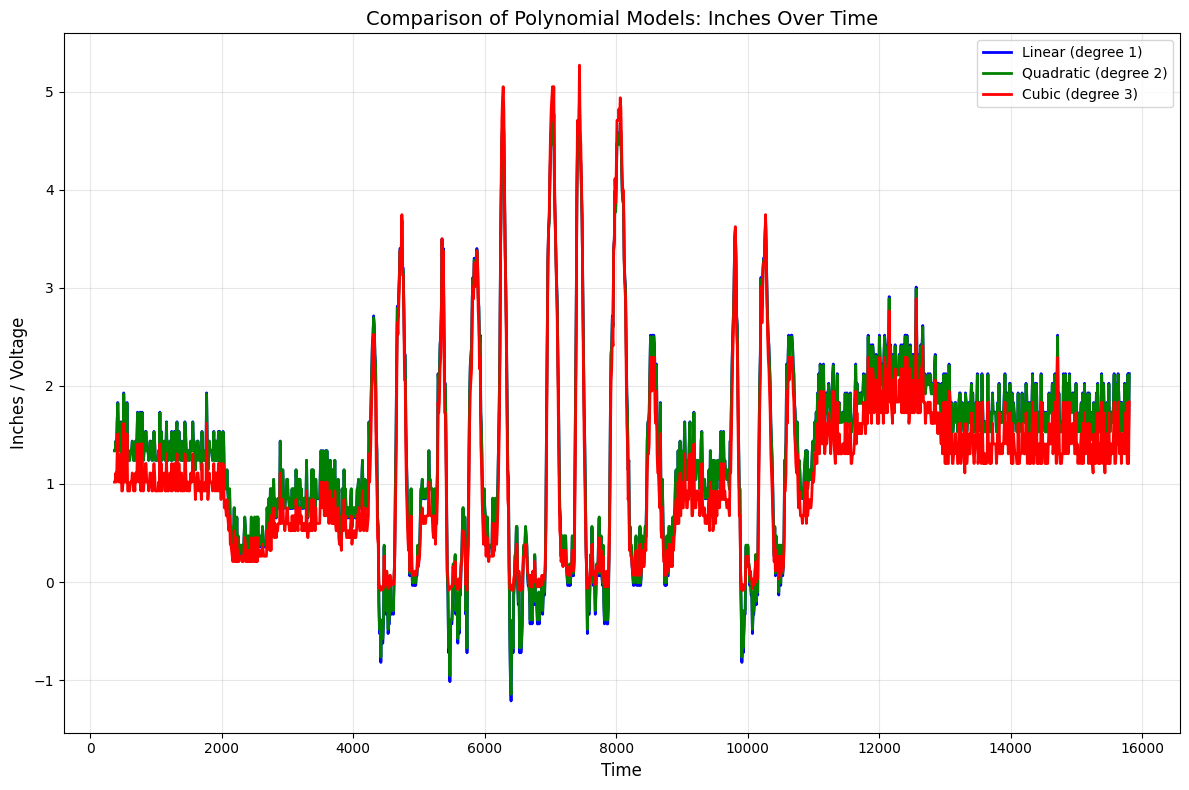

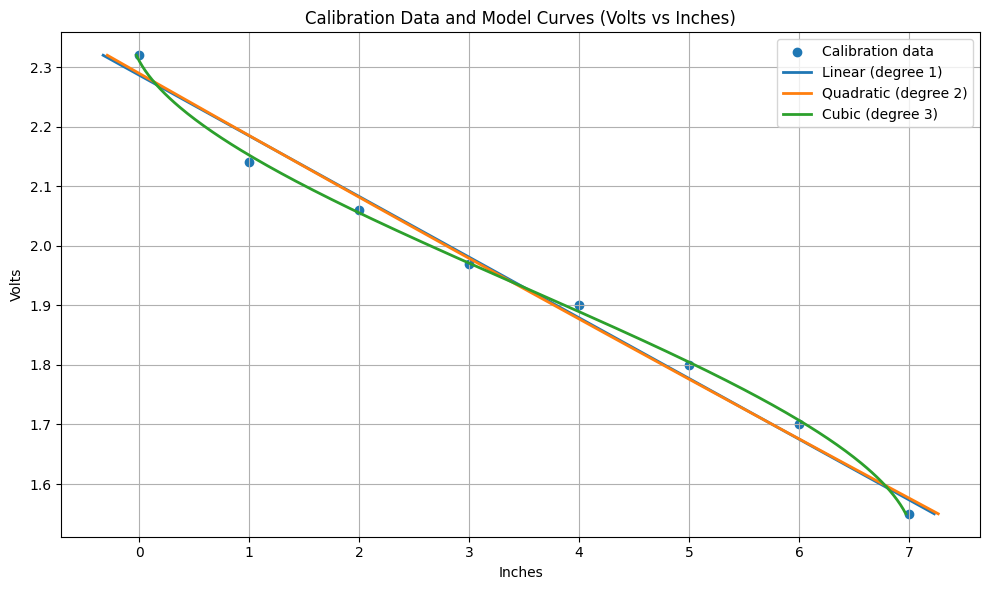

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
# Example of using it on csv and graphing
df_data = pd.read_csv('data/trial1.csv', sep=',')
#print(df_data.columns)
time = df_data['Interval|"ms"|0|0|1']
time_volts = df_data['Analog3|"Volts"|0.0|5.0|100']

df = pd.read_csv('calibration_data/leftWheelAN3.csv') #for calibration
inches = df["Displacement (in)"]
volts = df["Volts"]


models = [
    (fit_model(volts, inches, degree=1), "Linear (degree 1)"),
    (fit_model(volts, inches, degree=2), "Quadratic (degree 2)"),
    (fit_model(volts, inches, degree=3), "Cubic (degree 3)"),
]

results_df = pd.DataFrame({"time": time, "volt": time_volts})

for model, model_name in models:
    predicted_inches = [volt_to_inch(v, model) for v in time_volts]
    results_df[f"predicted_{model_name.replace(' ', '_').lower()}"] = predicted_inches

plt.figure(figsize=(12, 8))

colors = ['blue', 'green', 'red', 'yellow']
markers = ['o', 's', '^']
for i, (model, model_name) in enumerate(models):
    pred_col = f"predicted_{model_name.replace(' ', '_').lower()}"
    plt.plot(time, results_df[pred_col], 
             #marker=markers[i], 
             color=colors[i], 
             label=model_name,
             linewidth=2,
             markersize=6)


plt.xlabel("Time", fontsize=12)
plt.ylabel("Inches / Voltage", fontsize=12)
plt.title("Comparison of Polynomial Models: Inches Over Time", fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))

plt.scatter(inches, volts, label="Calibration data")

volt_range = np.linspace(min(volts), max(volts), 300)

for model, model_name in models:
    predicted_inches = [volt_to_inch(v, model) for v in volt_range]
    plt.plot(predicted_inches, volt_range, label=model_name, linewidth=2)

plt.xlabel("Inches")
plt.ylabel("Volts")
plt.title("Calibration Data and Model Curves (Volts vs Inches)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

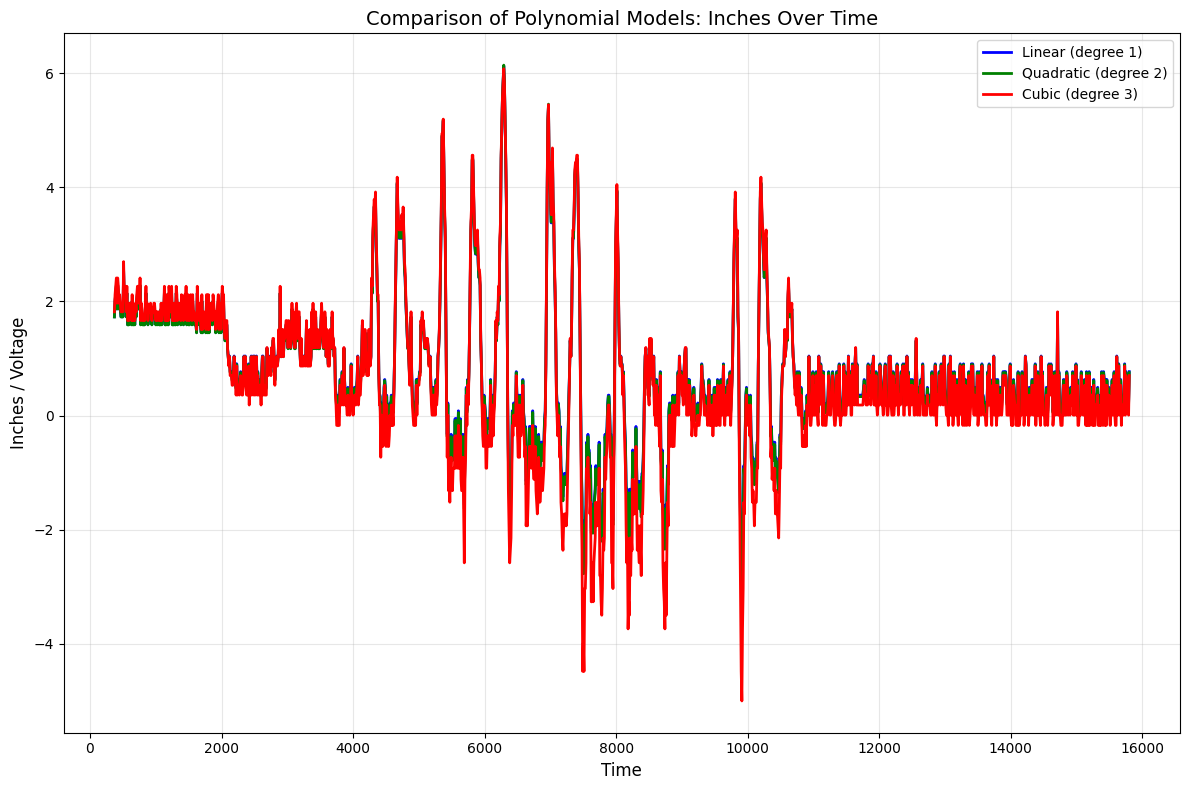

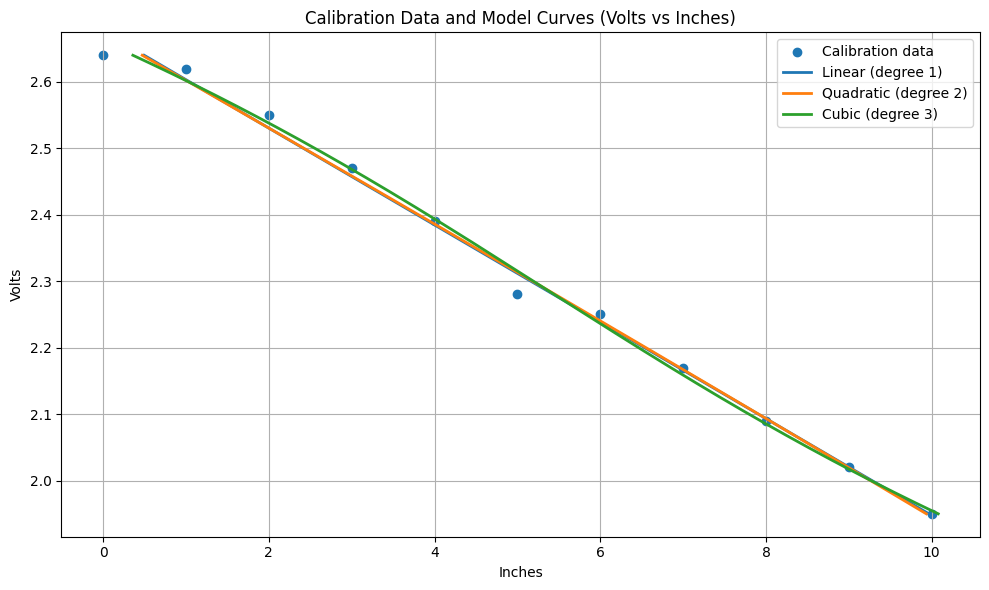

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
# Example of using it on csv and graphing
df_data = pd.read_csv('data/trial1.csv', sep=',')
#print(df_data.columns)
time = df_data['Interval|"ms"|0|0|1']
time_volts = df_data['Analog1|"Volts"|0.0|5.0|100']

df = pd.read_csv('calibration_data/rightWheelAN1.csv') #for calibration
inches = df["Displacement (in)"]
volts = df["Volts"]


models = [
    (fit_model(volts, inches, degree=1), "Linear (degree 1)"),
    (fit_model(volts, inches, degree=2), "Quadratic (degree 2)"),
    (fit_model(volts, inches, degree=3), "Cubic (degree 3)"),
]

results_df = pd.DataFrame({"time": time, "volt": time_volts})

for model, model_name in models:
    predicted_inches = [volt_to_inch(v, model) for v in time_volts]
    results_df[f"predicted_{model_name.replace(' ', '_').lower()}"] = predicted_inches

plt.figure(figsize=(12, 8))

colors = ['blue', 'green', 'red', 'yellow']
markers = ['o', 's', '^']
for i, (model, model_name) in enumerate(models):
    pred_col = f"predicted_{model_name.replace(' ', '_').lower()}"
    plt.plot(time, results_df[pred_col], 
             #marker=markers[i], 
             color=colors[i], 
             label=model_name,
             linewidth=2,
             markersize=6)


plt.xlabel("Time", fontsize=12)
plt.ylabel("Inches / Voltage", fontsize=12)
plt.title("Comparison of Polynomial Models: Inches Over Time", fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))

plt.scatter(inches, volts, label="Calibration data")

volt_range = np.linspace(min(volts), max(volts), 300)

for model, model_name in models:
    predicted_inches = [volt_to_inch(v, model) for v in volt_range]
    plt.plot(predicted_inches, volt_range, label=model_name, linewidth=2)

plt.xlabel("Inches")
plt.ylabel("Volts")
plt.title("Calibration Data and Model Curves (Volts vs Inches)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

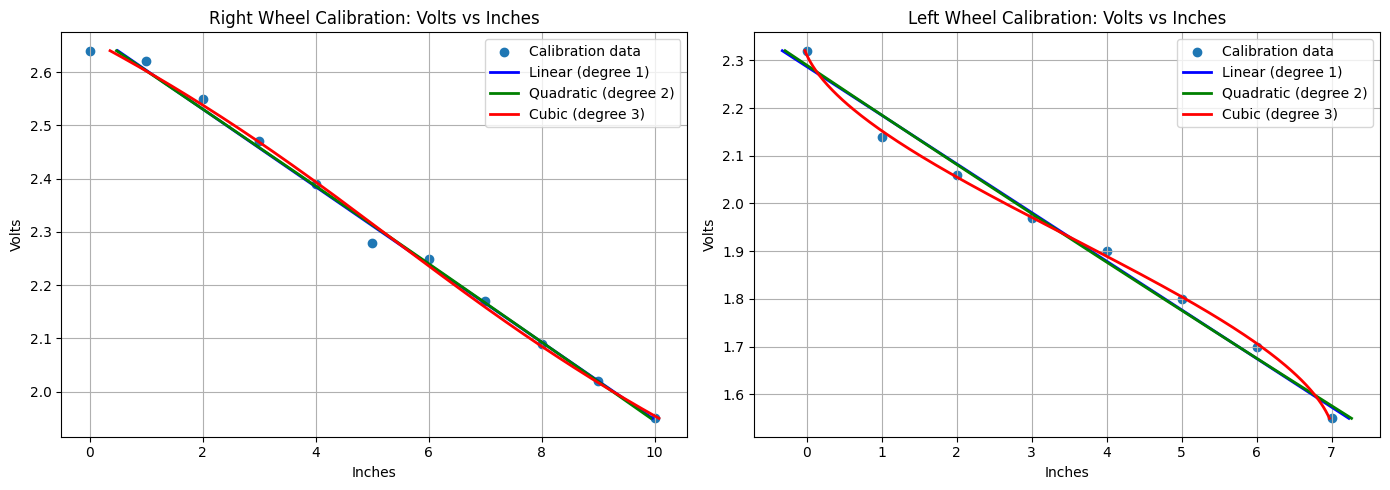

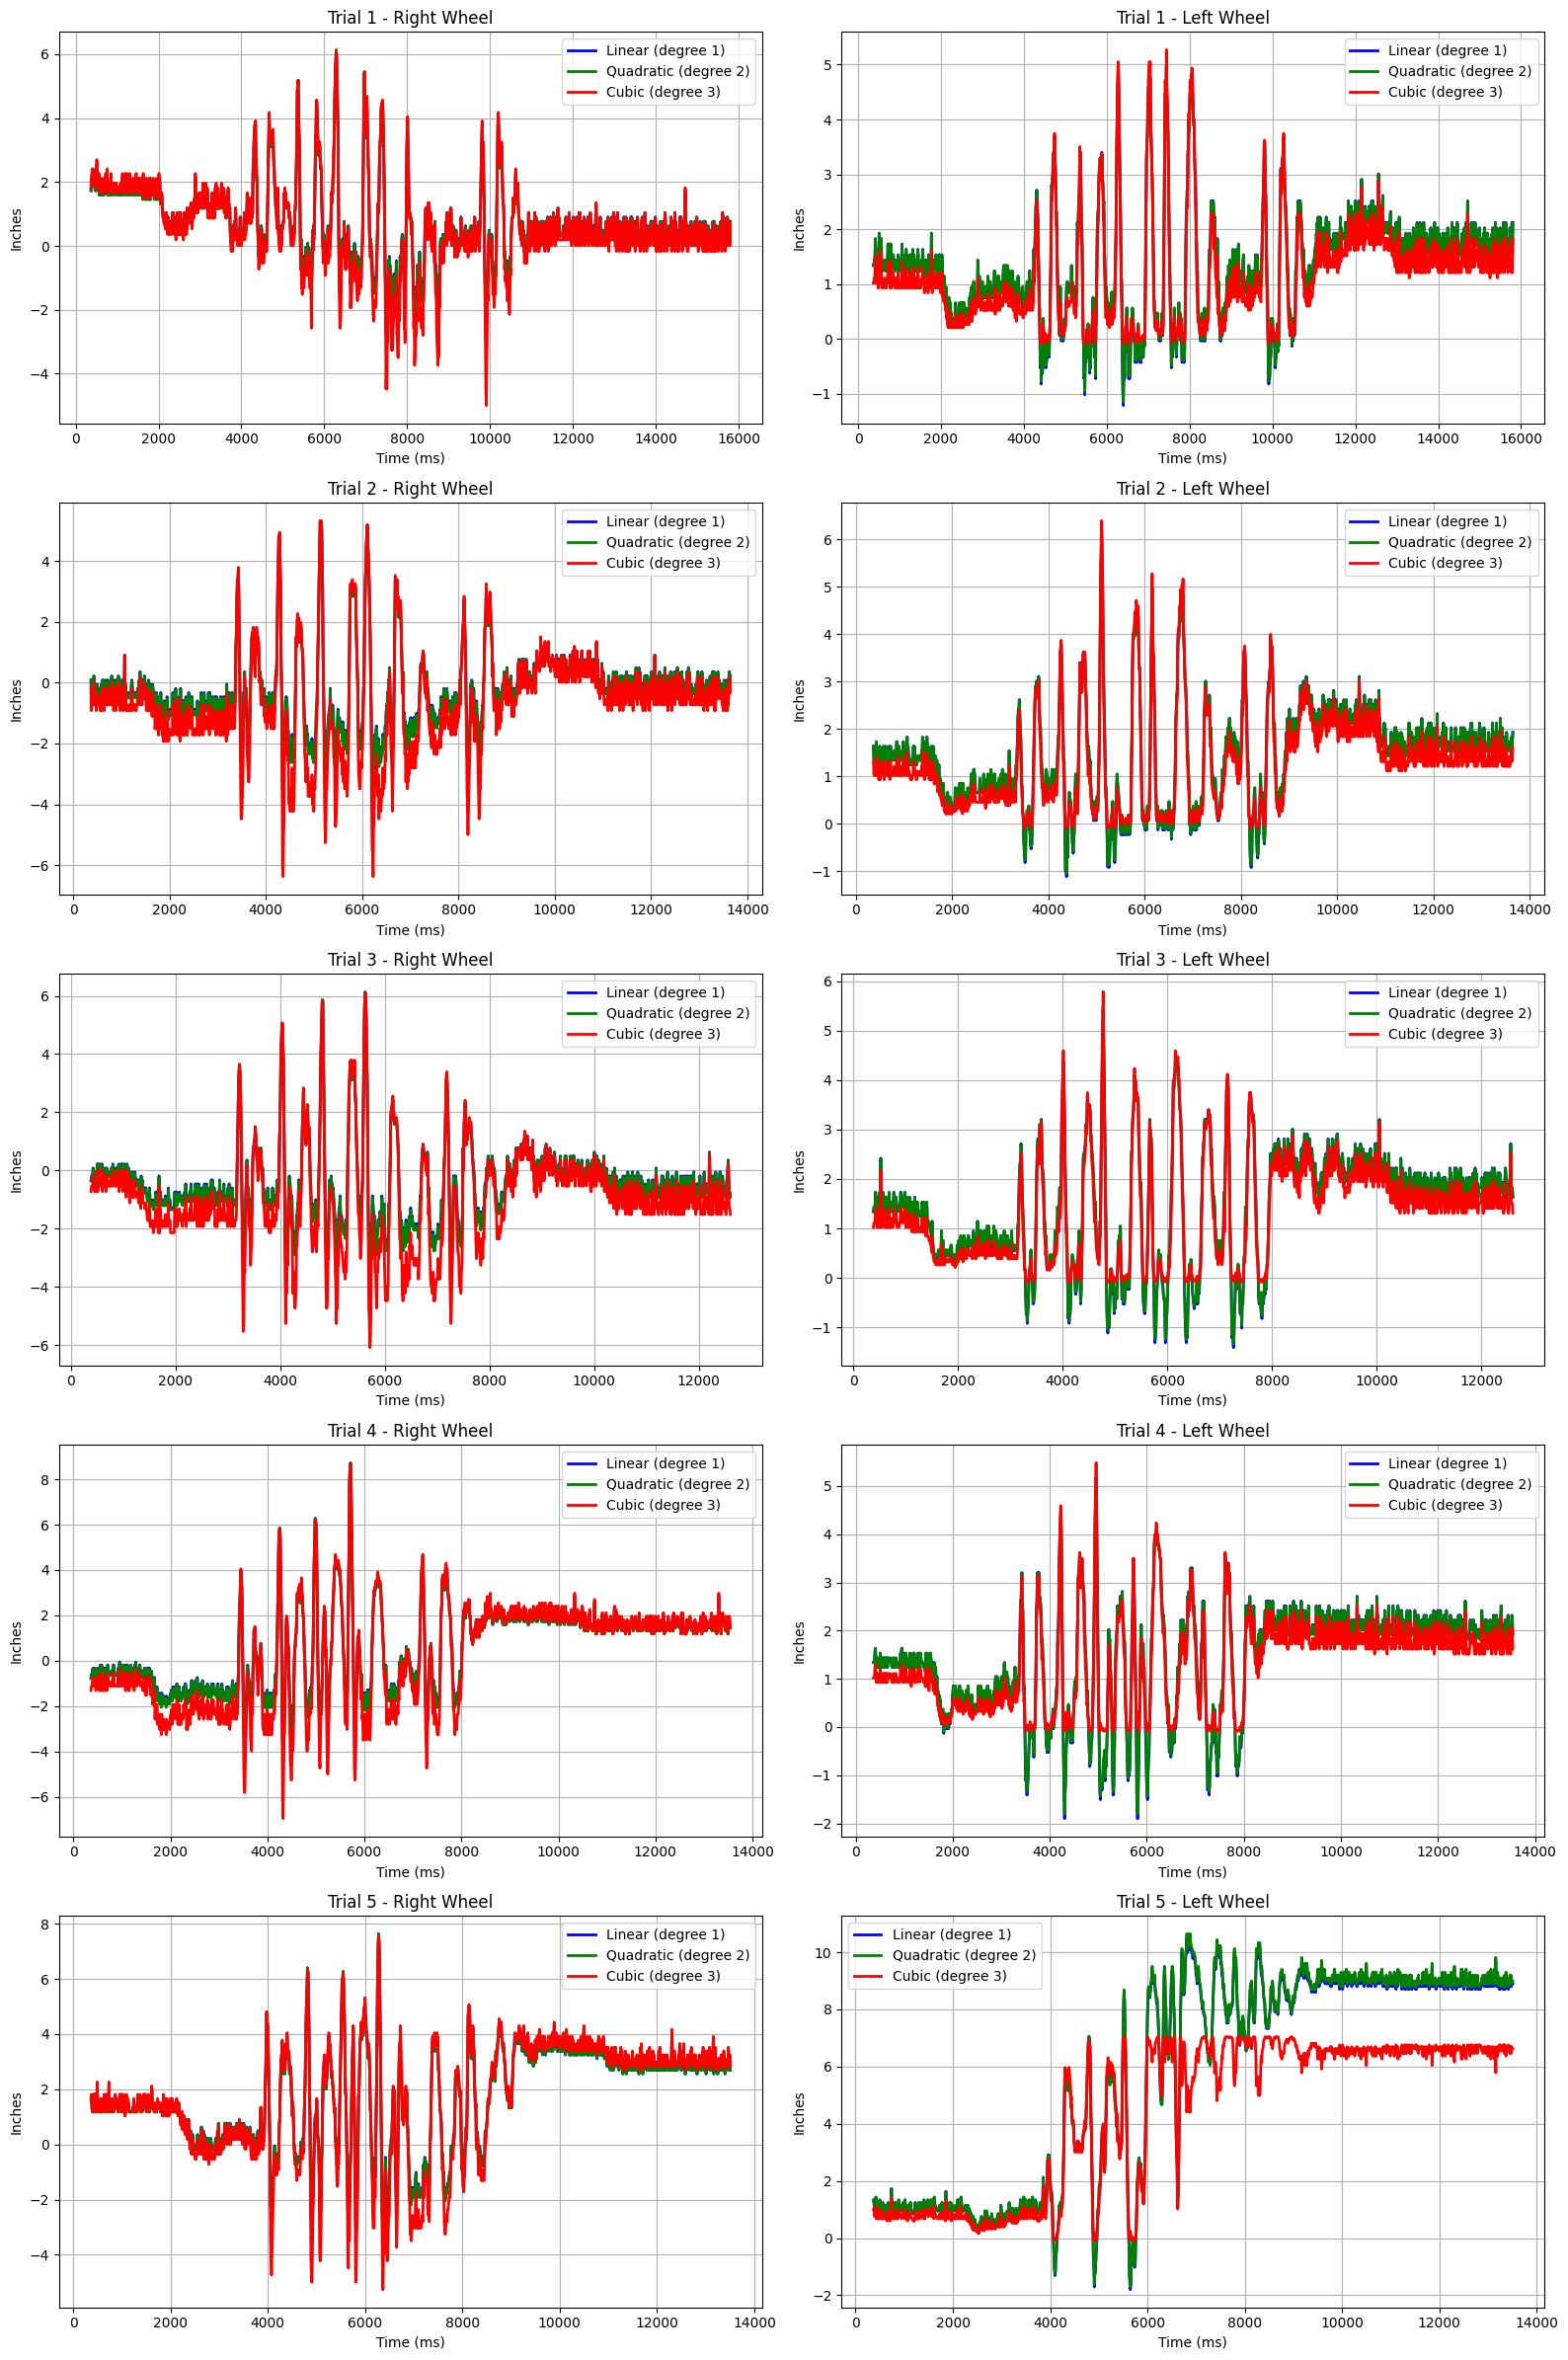

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Assumes these already exist:
# fit_model(volts, inches, degree)
# volt_to_inch(v, model)

time_col = 'Interval|"ms"|0|0|1'

wheel_info = {
    "Right Wheel": {
        "analog_col": 'Analog1|"Volts"|0.0|5.0|100',
        "cal_file": 'calibration_data/rightWheelAN1.csv'
    },
    "Left Wheel": {
        "analog_col": 'Analog3|"Volts"|0.0|5.0|100',
        "cal_file": 'calibration_data/leftWheelAN3.csv'
    }
}

model_specs = [
    (1, "Linear (degree 1)", "blue"),
    (2, "Quadratic (degree 2)", "green"),
    (3, "Cubic (degree 3)", "red"),
]

# ---------------------------
# Load calibration data + fit models
# ---------------------------
wheel_models = {}

for wheel_name, info in wheel_info.items():
    df_cal = pd.read_csv(info["cal_file"])
    inches = df_cal["Displacement (in)"]
    volts = df_cal["Volts"]

    models = []
    for degree, model_name, color in model_specs:
        model = fit_model(volts, inches, degree=degree)
        models.append((model, model_name, color))

    wheel_models[wheel_name] = {
        "inches": inches,
        "volts": volts,
        "models": models
    }

# ===========================
# 1) Calibration plots: 1x2
# ===========================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, wheel_name in zip(axes, ["Right Wheel", "Left Wheel"]):
    inches = wheel_models[wheel_name]["inches"]
    volts = wheel_models[wheel_name]["volts"]
    models = wheel_models[wheel_name]["models"]

    ax.scatter(inches, volts, label="Calibration data")

    volt_range = np.linspace(min(volts), max(volts), 300)

    for model, model_name, color in models:
        predicted_inches = [volt_to_inch(v, model) for v in volt_range]
        ax.plot(predicted_inches, volt_range, color=color, linewidth=2, label=model_name)

    ax.set_xlabel("Inches")
    ax.set_ylabel("Volts")
    ax.set_title(f"{wheel_name} Calibration: Volts vs Inches")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

# ===========================
# 2) Trial plots: 5x2
# ===========================
fig, axes = plt.subplots(5, 2, figsize=(16, 24), sharex=False, sharey=False)

for trial_num in range(1, 6):
    trial_file = f"data/trial{trial_num}.csv"
    df_data = pd.read_csv(trial_file)

    time = df_data[time_col]

    # -------- Right Wheel (left column) --------
    ax_right = axes[trial_num - 1, 0]
    right_volts = df_data[wheel_info["Right Wheel"]["analog_col"]]
    right_models = wheel_models["Right Wheel"]["models"]

    for model, model_name, color in right_models:
        predicted_inches = [volt_to_inch(v, model) for v in right_volts]
        ax_right.plot(
            time,
            predicted_inches,
            color=color,
            linewidth=2,
            label=model_name
        )

    ax_right.set_title(f"Trial {trial_num} - Right Wheel")
    ax_right.set_xlabel("Time (ms)")
    ax_right.set_ylabel("Inches")
    ax_right.grid(True)
    ax_right.legend()

    # -------- Left Wheel (right column) --------
    ax_left = axes[trial_num - 1, 1]
    left_volts = df_data[wheel_info["Left Wheel"]["analog_col"]]
    left_models = wheel_models["Left Wheel"]["models"]

    for model, model_name, color in left_models:
        predicted_inches = [volt_to_inch(v, model) for v in left_volts]
        ax_left.plot(
            time,
            predicted_inches,
            color=color,
            linewidth=2,
            label=model_name
        )

    ax_left.set_title(f"Trial {trial_num} - Left Wheel")
    ax_left.set_xlabel("Time (ms)")
    ax_left.set_ylabel("Inches")
    ax_left.grid(True)
    ax_left.legend()

plt.tight_layout()
plt.show()